# Verifier-Guided Reasoning MVP

This notebook demonstrates a **verifier-guided reasoning system** for training small language models on arithmetic and logic tasks. Instead of traditional RLHF (Reinforcement Learning from Human Feedback), we use **deterministic verifiers** to automatically score and filter reasoning traces, creating high-quality supervision data.

## Key Concepts

### Structured Reasoning Traces
- **TraceRecord**: A structured representation of a step-by-step solution (question → steps → answer)
- **Verifier**: Automated checker that validates each step (e.g., arithmetic correctness)
- **Preference Pairs**: Comparisons between good vs. bad traces, derived from verifier scores

### Workflow Overview
1. **Generate Candidates**: Use a base model to create multiple reasoning traces per prompt
2. **Verify & Score**: Run deterministic verifiers on each trace
3. **Filter/Reject**: Keep only traces that pass verification gates
4. **Train Models**: Use accepted traces for SFT, or preference pairs for DPO

### Why This Approach?
- **Deterministic**: No human labeling required - verifiers provide objective scores
- **Scalable**: Can generate supervision data automatically from any dataset
- **Transparent**: Each decision is traceable through the verifier logic

Notebook goals:
- Install dependencies and mount Google Drive
- Configure DVC (data versioning) and MLflow (experiment tracking)
- Run the arithmetic verifier demo
- Preview SFT and DPO training paths

In [25]:
from google.colab import drive
drive.mount('/content/drive')

# Optional: Create a dedicated project folder
import os
project_path = '/content/drive/MyDrive/RLHF_Logic_Framework'
os.makedirs(project_path, exist_ok=True)
print(f'Drive mounted. Project directory ready at: {project_path}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Project directory ready at: /content/drive/MyDrive/RLHF_Logic_Framework


# Verifier-Guided Reasoning MVP (Weeks 1-8)

This notebook is organized by roadmap week and designed as an employer-facing artifact for **data annotation + curation** roles.

What this notebook demonstrates:
- deterministic verifier-guided quality control for reasoning traces,
- reviewer controls with accept/reject/fix decisions,
- measurable best-of-N and rejection-sampling behavior,
- a narrow logic extension evaluated **separately** from arithmetic,
- reproducibility gates before publication artifacts.


## Section 0 (Project Explanation)

A full technical-but-accessible explanation is available in:
- `docs/section_0_project_explanation.md`

Read it before demoing if your audience is not deeply ML-specialized.


In [26]:
import os
import sys
import json
from pathlib import Path
from collections import Counter, defaultdict
from pprint import pprint

IN_COLAB = 'google.colab' in sys.modules
print({'in_colab': IN_COLAB, 'python': sys.version.split()[0]})

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

print('pandas:', 'ok' if pd is not None else 'missing')
print('matplotlib:', 'ok' if plt is not None else 'missing')


{'in_colab': True, 'python': '3.12.13'}
pandas: ok
matplotlib: ok



Generate keypair for ssh, copy key generated in this notebook my https://github.com/settings/keys, then add the GitHub generated secret key as a varible named GH_PAT to the notebook secrets and click 'notebook access' toggle.



In [27]:
import os
import shutil

# Define a persistent path in your Google Drive
drive_ssh_path = os.path.join(project_path, '.ssh_keys')
os.makedirs(drive_ssh_path, exist_ok=True)

key_name = 'id_rsa'
local_ssh_dir = os.path.expanduser('~/.ssh')
os.makedirs(local_ssh_dir, exist_ok=True)

drive_key = os.path.join(drive_ssh_path, key_name)
local_key = os.path.join(local_ssh_dir, key_name)

# 1. If key exists in Drive but not locally, copy it to local runtime
if os.path.exists(drive_key) and not os.path.exists(local_key):
    print('Restoring existing SSH key from Google Drive...')
    shutil.copy(drive_key, local_key)
    shutil.copy(drive_key + '.pub', local_key + '.pub')
    os.chmod(local_key, 0o600)

# 2. If no key exists anywhere, generate one and save to Drive
if not os.path.exists(local_key):
    print('Generating new persistent SSH key...')
    !ssh-keygen -t rsa -b 4096 -f {local_key} -N ""
    shutil.copy(local_key, drive_key)
    shutil.copy(local_key + '.pub', drive_key + '.pub')

# Display public key for one-time GitHub setup
with open(local_key + '.pub', 'r') as f:
    print('\nYour Public Key (Add this to GitHub once):\n')
    print(f.read())


Your Public Key (Add this to GitHub once):

ssh-rsa AAAAB3NzaC1yc2EAAAADAQABAAACAQC475PEhKuDZUE4ZL+LaSNNSK354HSyP7MMSde0dn1iJ7g+zeUEkmy0l/w9WdoRWGciHR4QPz0cn/HOjP2A73SbfJ/xiscHNHmHDLDG8bswLYWN5E60UscHiYqy+Wr2EWJrR1gcit/mvCllNTKmqv1sJF0paFMdaZdC52m1HNSCVzT0mIdLeFZaY3EKquM+aKtsAmjYxCgGpYcincpapEdyTYPppXwrEAdMqLKh9u4Jrc81ErlTa2K/eK7BtnMbWTYXY8uCFhW7xp4ca1Ugj+QVh/FeBieyFzWAgpyoC70FBihiRp/drOQtLHvXjp8t98eJnB3eAtzMn4gTo2lW7ur8GLq8cHI3yuBd/SvDRGEHyCKgctca6vU0DLkG0vf3pQNFcnMeHbxnzVfdD89B0Rzdu3mnLNXh4BoxmJasLMl2VooqTgUqse6VwkfWctecuCRzW8WRSYiKsitLEA1ubZakiBRPPkPCOyU39O6euurqycsNqCVRws9azempgpEF9ul3eNlUrTLacUo8Mz5yPhJRK/ci2TzA36H3xETgxWM7ZFHgEH+Tm6OmAknMjSOnyJVq/okUYdJUzPhPXDCX8/8OnuP2xhO4u0KXettjWQRnxvlabCOdKAaFg7cwEoAfZsRmuZ/yZpjLIOddJ3O96wwuKfGHpAoe7Kn5OEVKPaAZ0Q== root@47406eaccc00



In [28]:
import os
import sys
import subprocess
from pathlib import Path

# --- CONFIGURATION ---
repo_name = 'RLHF-Logic-Verification-Framework'
repo_ssh_url = 'git@github.com:datasentient1/RLHF-Logic-Verification-Framework.git'
# ---------------------

if IN_COLAB:
    workspace = Path('/content')
    repo_root = workspace / repo_name

    # Ensure GitHub is in known_hosts to avoid interactive prompt
    !mkdir -p ~/.ssh
    !ssh-keyscan github.com >> ~/.ssh/known_hosts

    if not repo_root.exists():
        print(f'Cloning repository via SSH...')
        env = os.environ.copy()
        env['GIT_TERMINAL_PROMPT'] = '0'
        result = subprocess.run(['git', 'clone', repo_ssh_url, str(repo_root)], capture_output=True, text=True, env=env)

        if result.returncode != 0:
            print(f'--- DEBUG INFO ---')
            print(f'Exit Code: {result.returncode}')
            print(f'Standard Error: {result.stderr}')
            print(f'------------------')
            raise RuntimeError('Git clone failed. Ensure your SSH key is added to GitHub.')

    os.chdir(repo_root)
else:
    repo_root = Path.cwd()

print('cwd ->', os.getcwd())

src_path = str(repo_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print('Installing package with Colab extras...')
get_ipython().system('python -m pip -q install -e .[colab]')
print('Install complete.')

# github.com:22 SSH-2.0-a59182e
# github.com:22 SSH-2.0-a59182e
# github.com:22 SSH-2.0-a59182e
# github.com:22 SSH-2.0-a59182e
# github.com:22 SSH-2.0-a59182e
cwd -> /content/RLHF-Logic-Verification-Framework
Installing package with Colab extras...
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for verifier-guided-reasoning (pyproject.toml) ... done
Install complete.


## Weeks 1-2: Foundation Check

Goal: prove the base arithmetic pipeline is reproducible and trackable.


In [29]:
# Week 1-2 / Step 1: clone + install

repo_name = 'RLHF-Logic-Verification-Framework'
repo_https = 'https://github.com/datasentient1/RLHF-Logic-Verification-Framework.git'

if IN_COLAB:
    workspace = Path('/content')
    repo_root = workspace / repo_name
    if not repo_root.exists():
        print(f'Cloning {repo_https} ...')
        get_ipython().system(f'git clone {repo_https}')
    os.chdir(repo_root)
else:
    repo_root = Path.cwd()

print('cwd ->', os.getcwd())

src_path = str(repo_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print('Installing package with Colab extras...')
get_ipython().system('python -m pip -q install -e .[colab]')
print('Install complete.')


cwd -> /content/RLHF-Logic-Verification-Framework
Installing package with Colab extras...
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for verifier-guided-reasoning (pyproject.toml) ... done
Install complete.


## Arithmetic SFT Path

The public MVP stays arithmetic-first:

- `MU-NLPC/Calc-svamp` for seed structured traces
- `openai/gsm8k` for benchmark and augmentation
- verifier gates before SFT export
- `Qwen/Qwen2.5-1.5B-Instruct` as the default base model
- `Qwen/Qwen2.5-Math-1.5B-Instruct` as the optional comparison model

Do not move to DPO until the verifier and accepted-trace pipeline are stable.

## DPO Path (Stretch Goal)

Direct Preference Optimization uses preference pairs to align models with desired behavior:

- **Generate Candidates**: Create multiple traces per prompt using the base model
- **Score with Verifier**: Get objective scores for each trace
- **Build Preference Pairs**: Compare traces within the same prompt (higher score = chosen, lower = rejected)
- **Train DPO**: Optimize the model to prefer chosen over rejected responses

### Benefits over SFT
- **Pairwise Comparisons**: Learns relative preferences, not just absolute quality
- **Fewer Parameters**: More efficient than full RLHF
- **Verifier-Driven**: Preferences come from objective, deterministic scoring

### Implementation Steps
1. Generate candidate traces for a dataset
2. Run verifier scoring
3. Mine preference pairs with sufficient margin
4. Train DPO model using the pairs

In [30]:
# Week 1-2 / Step 3: run arithmetic demo and inspect outputs

try:
    import mlflow
    import pyarrow
except (ImportError, ValueError):
    print('Fixing pyarrow/mlflow binary incompatibility in Colab...')
    !pip install -q --upgrade pyarrow mlflow
    print('Restarting runtime to apply changes...')
    import os
    os._exit(0) # Automatically restarts the Colab runtime

from verifier_guided_reasoning.pipeline import run_small_demo
from pathlib import Path
from pprint import pprint
import pandas as pd
import shutil

# Define persistent tracking root in Drive
mlflow_root = Path('/content/drive/MyDrive/RLHF_Logic_Framework/mlruns')

# Cleanup corrupted local tracking if it exists to prevent MLflow conflicts
local_corrupted = Path('artifacts/mlruns')
if local_corrupted.exists():
    shutil.rmtree(local_corrupted)

mlflow_root.mkdir(parents=True, exist_ok=True)
print(f'Using persistent tracking root: {mlflow_root}')

arith_summary = run_small_demo(
    output_path='artifacts/eval/demo_summary.json',
    report_markdown_path='artifacts/eval/demo_report.md',
    tracker_root=str(mlflow_root),
)

print('Arithmetic metrics:')
pprint({k: arith_summary[k] for k in ['num_traces', 'final_accuracy', 'pass_rate', 'error_counts']})

if 'pd' in globals() and pd is not None:
    display(pd.DataFrame(arith_summary.get('traces', [])))

report_path = Path('artifacts/eval/demo_report.md')
print('\nReport path:', report_path)
if report_path.exists():
    print(report_path.read_text(encoding='utf-8')[:900])

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.1

Using persistent tracking root: /content/drive/MyDrive/RLHF_Logic_Framework/mlruns
Arithmetic metrics:
{'error_counts': {'numeric_inconsistency': 1},
 'final_accuracy': 1.0,
 'num_traces': 2,
 'pass_rate': 0.75}


,sample_id,source_dataset,final_status,num_failures,error_types
0,demo-good-1,openai/gsm8k,pass,0,[]
1,demo-bad-1,openai/gsm8k,pass,1,[numeric_inconsistency]



Report path: artifacts/eval/demo_report.md
# Verifier-Guided Reasoning Demo Report

## Summary
- Traces evaluated: 2
- Final-answer accuracy: 100.00%
- Mean verifier pass rate: 75.00%

## Status Counts
- fail: 1
- pass: 3

## Error Counts
- numeric_inconsistency: 1

## Trace Diagnostics
- `demo-good-1` (openai/gsm8k): final=pass, failures=0, errors=[]
- `demo-bad-1` (openai/gsm8k): final=pass, failures=1, errors=['numeric_inconsistency']



## Weeks 3-4: Data Curation + Reviewer Controls + Export

Goal: run an annotation-style workflow with explicit reviewer actions.


In [31]:
# Generate preference pairs (run this once to create training data)
# !python scripts/generate_dpo_pairs.py --model "Qwen/Qwen2.5-1.5B-Instruct" --num-prompts 50 --output data/processed/dpo_pairs.jsonl

# Or use user-selected pairs from the curation tool above
# !python scripts/run_dpo.py --pairs-file data/processed/user_selected_pairs.jsonl --model "Qwen/Qwen2.5-1.5B-Instruct" --output-dir artifacts/models/dpo --tracker-root "$MLFLOW_TRACKING_URI"

print("DPO training cells updated. Use user-selected pairs or generated pairs for training.")

DPO training cells updated. Use user-selected pairs or generated pairs for training.


## DPO Training (Stretch Goal)

Once you have preference pairs, train a DPO model to learn from verifier-derived preferences.

In [32]:
import sys
import os
from pathlib import Path
from datasets import load_dataset

# Diagnostic: Check Math-Shepherd schema directly
print('Checking Math-Shepherd schema...')
try:
    # Using a try-except block to gracefully handle Hub access issues
    ds_peek = load_dataset('pku-alignment/Math-Shepherd', split='train', streaming=True)
    sample_row = next(iter(ds_peek))
    print(f'Actual Math-Shepherd columns: {list(sample_row.keys())}')
except Exception as e:
    print(f'Math-Shepherd unavailable on Hub: {e}')

# Advanced fix for dataset schema mapping in the source code
datasets_file = Path('src/verifier_guided_reasoning/datasets.py')
if datasets_file.exists():
    content = datasets_file.read_text()
    # Patch mapping to use .get() to prevent KeyErrors on 'other_output' or prompt keys
    content = content.replace('"prompt": row["instruction"]', '"prompt": row.get("input", row.get("question", ""))')
    content = content.replace('"chosen": row["output"]', '"chosen": row.get("output", row.get("response", ""))')
    content = content.replace('"rejected": row["other_output"]', '"rejected": row.get("other_output", row.get("rejected", ""))')
    datasets_file.write_text(content)

# Reload the module to apply changes
if 'verifier_guided_reasoning.datasets' in sys.modules:
    import importlib
    import verifier_guided_reasoning.datasets
    importlib.reload(verifier_guided_reasoning.datasets)

if IN_COLAB:
    get_ipython().run_line_magic('pip', 'install -q ipywidgets datasets')
    from google.colab import userdata
    try:
        os.environ['HF_TOKEN'] = userdata.get('HF_April_RLHF_Project')
    except Exception as e:
        print(f'Warning: HF_April_RLHF_Project secret not found.')

import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
from verifier_guided_reasoning.datasets import load_math_shepherd_pairs, load_hh_rlhf_pairs

print('Loading preference pairs...')
math_pairs = []
try:
    math_pairs = load_math_shepherd_pairs(num_samples=50)
    print(f'Loaded {len(math_pairs)} pairs from Math-Shepherd')
except Exception as e:
    print(f'Math-Shepherd load skipped: {e}')

hh_pairs = load_hh_rlhf_pairs(num_samples=50)
print(f'Loaded {len(hh_pairs)} pairs from HH-RLHF')

all_pairs = math_pairs + hh_pairs
user_selections = []

dataset_selector = widgets.Dropdown(
    options=['Math-Shepherd (Math)', 'HH-RLHF (General)', 'Combined'],
    value='HH-RLHF (General)',
    description='Dataset:'
)
pair_selector = widgets.Dropdown(options=[], description='Select Pair:')
output_area = widgets.Output()

def update_pair_options(change=None):
    ds = dataset_selector.value
    curr = math_pairs if ds == 'Math-Shepherd (Math)' else hh_pairs if ds == 'HH-RLHF (General)' else all_pairs
    if not curr:
        pair_selector.options = ['No pairs available']
    else:
        pair_selector.options = [f'Pair {i+1}: {p["prompt"][:50]}...' for i, p in enumerate(curr)]

dataset_selector.observe(update_pair_options, names='value')
update_pair_options()
display(dataset_selector, pair_selector, output_area)

Checking Math-Shepherd schema...
Math-Shepherd unavailable on Hub: Dataset 'pku-alignment/Math-Shepherd' doesn't exist on the Hub or cannot be accessed.
Loading preference pairs...
Loaded 50 pairs from Math-Shepherd
Loaded 50 pairs from HH-RLHF


Dropdown(description='Dataset:', index=1, options=('Math-Shepherd (Math)', 'HH-RLHF (General)', 'Combined'), v…

Dropdown(description='Select Pair:', options=('Pair 1: \n\nHuman: What are some cuss words in english?\n\nAss.…

Output()

## Interactive Preference Pair Selection

Use this interactive widget to manually review and select preference pairs for DPO training. This allows human curation when verifier scores are close or for edge cases.

In [33]:
# Week 3-4 / Step 1: normalize + gate source rows

from verifier_guided_reasoning.datasets import build_demo_rows, normalize_gsm8k_record, gate_trace_record

rows = build_demo_rows()
traces = [normalize_gsm8k_record(row, split='demo') for row in rows]

gated_rows = []
for trace in traces:
    gate = gate_trace_record(trace)
    gated_rows.append({
        'sample_id': trace.sample_id,
        'accepted': gate.accepted,
        'schema_valid': gate.schema_valid,
        'verifier_agreement': gate.verifier_agreement,
        'reasons': ', '.join(gate.reasons) if gate.reasons else '',
        'question_preview': trace.question[:90] + '...'
    })

if pd is not None:
    display(pd.DataFrame(gated_rows))
else:
    pprint(gated_rows)


,sample_id,accepted,schema_valid,verifier_agreement,reasons,question_preview
0,demo-good-1,True,True,True,,A baker makes 12 muffins in the morning and 8 ...
1,demo-bad-1,False,True,False,numeric_inconsistency,Maya saves $10 on Monday and $5 on Tuesday. Ho...


In [34]:
# Week 3-4 / Step 2: generate candidates + build review records

from verifier_guided_reasoning.generation import build_mock_generator, generate_candidates
from verifier_guided_reasoning.review import build_review_records

candidates = generate_candidates(
    rows=rows,
    generator=build_mock_generator(),
    model_name='mock-candidate-generator',
    split='train',
)
review_records = build_review_records(candidates, model_name='mock-candidate-generator', split='train')

preview_rows = [
    {
        'prompt_id': r.prompt_id,
        'candidate_id': r.candidate_id,
        'verifier_pass': r.verifier_pass,
        'verifier_score': round(r.verifier_score, 3),
        'raw_output_preview': r.raw_output[:80].replace('\n', ' ') + '...'
    }
    for r in review_records
]
if pd is not None:
    display(pd.DataFrame(preview_rows))
else:
    pprint(preview_rows)

,prompt_id,candidate_id,verifier_pass,verifier_score,raw_output_preview
0,demo-good-1,demo-good-1-c1,False,0.25,Solve: A baker makes 12 muffins in the morning...
1,demo-good-1,demo-good-1-c2,False,0.00,Solve: A baker makes 12 muffins in the morning...
2,demo-good-1,demo-good-1-c3,False,0.00,Solve: A baker makes 12 muffins in the morning...
3,demo-bad-1,demo-bad-1-c1,False,0.25,Solve: Maya saves $10 on Monday and $5 on Tues...
4,demo-bad-1,demo-bad-1-c2,False,0.00,Solve: Maya saves $10 on Monday and $5 on Tues...
5,demo-bad-1,demo-bad-1-c3,False,0.00,Solve: Maya saves $10 on Monday and $5 on Tues...


In [35]:
# Week 3-4 / Step 3: reviewer UI (accept/reject/fix + notes + popup)

from IPython.display import display, HTML, Javascript

try:
    import ipywidgets as widgets
except Exception as exc:
    raise RuntimeError('ipywidgets required. Run: pip install ipywidgets') from exc

from verifier_guided_reasoning.review import summarize_review_metrics

by_prompt = defaultdict(list)
for rec in review_records:
    by_prompt[rec.prompt_id].append(rec)
for prompt_id in by_prompt:
    by_prompt[prompt_id] = sorted(by_prompt[prompt_id], key=lambda x: x.verifier_score, reverse=True)

controls = {}
widget_blocks = []

for prompt_id, group in by_prompt.items():
    widget_blocks.append(widgets.HTML(value=f"<h4>Prompt {prompt_id}</h4><div>{group[0].prompt}</div>"))
    for rec in group:
        action = widgets.Dropdown(
            options=['reject', 'accept', 'fix', 'needs_second_review'],
            value='reject',
            description='Label:',
            layout=widgets.Layout(width='260px'),
        )
        notes = widgets.Textarea(
            value='',
            placeholder='Why this action?',
            description='Notes:',
            layout=widgets.Layout(width='620px', height='70px'),
        )
        score = widgets.FloatSlider(
            value=float(rec.verifier_score),
            min=0,
            max=1,
            step=0.05,
            description='Score:',
            layout=widgets.Layout(width='430px'),
        )

        errors = sorted({vr.get('error_type') for vr in rec.verifier_results if vr.get('error_type')})
        err = ', '.join(errors) if errors else 'none'
        widget_blocks.append(
            widgets.HTML(
                value=(
                    "<div style='border:1px solid #ddd;padding:10px;border-radius:8px;margin:6px 0;background:#fafafa;'>"
                    f"<b>{rec.candidate_id}</b> | verifier_score=<b>{rec.verifier_score:.2f}</b> | errors=<code>{err}</code>"
                    f"<details><summary>Raw output</summary><pre style='white-space:pre-wrap;'>{rec.raw_output}</pre></details>"
                    "</div>"
                )
            )
        )
        widget_blocks.append(widgets.HBox([action, score]))
        widget_blocks.append(notes)
        controls[rec.review_id] = {'record': rec, 'action': action, 'notes': notes, 'score': score}

save_btn = widgets.Button(description='Save Labels', button_style='success', icon='check')
preview_btn = widgets.Button(description='Preview Labels', button_style='info', icon='table')
out = widgets.Output()


def _apply_labels():
    for ui in controls.values():
        rec = ui['record']
        rec.curator_action = ui['action'].value
        rec.curator_score = float(ui['score'].value)
        rec.curator_notes = ui['notes'].value.strip() or None


def _on_preview(_):
    _apply_labels()
    rows = [
        {
            'review_id': rec.review_id,
            'prompt_id': rec.prompt_id,
            'candidate_id': rec.candidate_id,
            'verifier_score': rec.verifier_score,
            'curator_action': rec.curator_action,
            'curator_score': rec.curator_score,
            'curator_notes': rec.curator_notes or '',
        }
        for rec in review_records
    ]
    with out:
        out.clear_output(wait=True)
        if pd is not None:
            display(pd.DataFrame(rows).sort_values(['prompt_id', 'verifier_score'], ascending=[True, False]))
        else:
            pprint(rows)


def _on_save(_):
    _apply_labels()
    metrics = summarize_review_metrics(review_records)
    with out:
        out.clear_output(wait=True)
        display(HTML(
            "<div style='padding:10px;background:#e8f5e9;border:1px solid #66bb6a;border-radius:8px;'>"
            "<b>Labels saved.</b><br>"
            f"Acceptance rate: {metrics['acceptance_rate']:.2%} | "
            f"Disagreement: {metrics['curator_verifier_disagreement_rate']:.2%}"
            "</div>"
        ))
        pprint(metrics)
    try:
        display(Javascript("alert('Week 3-4 labels saved. Ready for export.')"))
    except Exception:
        pass

preview_btn.on_click(_on_preview)
save_btn.on_click(_on_save)

display(widgets.HBox([preview_btn, save_btn]))
display(widgets.VBox(widget_blocks))
display(out)


Output()

In [36]:
# Week 3-4 / Step 4: export curated artifacts

from verifier_guided_reasoning.datasets import write_jsonl
from verifier_guided_reasoning.review import write_review_jsonl, export_sft_examples, export_preference_pairs, summarize_review_metrics

curation_dir = Path('artifacts/curation')
curation_dir.mkdir(parents=True, exist_ok=True)

review_path = curation_dir / 'review_batch_annotated.jsonl'
sft_path = curation_dir / 'sft_curated.jsonl'
prefs_path = curation_dir / 'preferences_curated.jsonl'

write_review_jsonl(review_records, review_path)
sft_examples = export_sft_examples(review_records)
pref_pairs = export_preference_pairs(review_records, min_margin=0.0)
write_jsonl(sft_examples, sft_path)
write_jsonl([p.to_dict() for p in pref_pairs], prefs_path)

review_metrics = summarize_review_metrics(review_records)
pprint({
    'review_records': len(review_records),
    'sft_examples': len(sft_examples),
    'preference_pairs': len(pref_pairs),
    'acceptance_rate': review_metrics['acceptance_rate'],
    'artifacts': [str(review_path), str(sft_path), str(prefs_path)],
})


{'acceptance_rate': 0.0,
 'artifacts': ['artifacts/curation/review_batch_annotated.jsonl',
               'artifacts/curation/sft_curated.jsonl',
               'artifacts/curation/preferences_curated.jsonl'],
 'preference_pairs': 0,
 'review_records': 6,
 'sft_examples': 0}


In [37]:
# Week 3-4 / Step 5: SFT configuration snapshot

TRAINING_CONFIG = {
    'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
    'comparison_model': 'Qwen/Qwen2.5-Math-1.5B-Instruct',
    'tuning_method': 'qlora',
    'max_seq_length': 2048,
    'datasets': {
        'sft_input': 'artifacts/curation/sft_curated.jsonl',
        'preference_input': 'artifacts/curation/preferences_curated.jsonl',
        'benchmark': 'openai/gsm8k',
    },
}

pprint(TRAINING_CONFIG)


{'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'comparison_model': 'Qwen/Qwen2.5-Math-1.5B-Instruct',
 'datasets': {'benchmark': 'openai/gsm8k',
              'preference_input': 'artifacts/curation/preferences_curated.jsonl',
              'sft_input': 'artifacts/curation/sft_curated.jsonl'},
 'max_seq_length': 2048,
 'tuning_method': 'qlora'}


## Weeks 5-6: Candidate Selection + Diagnostics (Implemented)


In [38]:
# Week 5-6 / Step 1: best-of-N reranking analysis

prompt_groups = defaultdict(list)
for rec in review_records:
    prompt_groups[rec.prompt_id].append(rec)

comparison_rows = []
for prompt_id, group in prompt_groups.items():
    group_sorted = sorted(group, key=lambda x: x.candidate_id)
    baseline = group_sorted[0]
    best = max(group, key=lambda x: x.verifier_score)
    comparison_rows.append({
        'prompt_id': prompt_id,
        'baseline_candidate': baseline.candidate_id,
        'baseline_score': baseline.verifier_score,
        'baseline_pass': baseline.verifier_pass,
        'best_candidate': best.candidate_id,
        'best_score': best.verifier_score,
        'best_pass': best.verifier_pass,
        'score_gain': best.verifier_score - baseline.verifier_score,
    })

if pd is not None:
    display(pd.DataFrame(comparison_rows))
else:
    pprint(comparison_rows)

baseline_pass_rate = sum(1 for row in comparison_rows if row['baseline_pass']) / max(len(comparison_rows), 1)
best_pass_rate = sum(1 for row in comparison_rows if row['best_pass']) / max(len(comparison_rows), 1)
print({'baseline_pass_rate': baseline_pass_rate, 'best_of_n_pass_rate': best_pass_rate})


,prompt_id,baseline_candidate,baseline_score,baseline_pass,best_candidate,best_score,best_pass,score_gain
0,demo-good-1,demo-good-1-c1,0.25,False,demo-good-1-c1,0.25,False,0.0
1,demo-bad-1,demo-bad-1-c1,0.25,False,demo-bad-1-c1,0.25,False,0.0


{'baseline_pass_rate': 0.0, 'best_of_n_pass_rate': 0.0}


In [39]:
# Week 5-6 / Step 2: rejection sampling threshold UI

import ipywidgets as widgets

threshold = widgets.FloatSlider(value=0.5, min=0, max=1, step=0.05, description='Min score:')
apply_btn = widgets.Button(description='Apply', button_style='primary')
out = widgets.Output()


def _apply(_):
    th = float(threshold.value)
    kept = [rec for rec in review_records if rec.verifier_score >= th]
    rejected = [rec for rec in review_records if rec.verifier_score < th]
    with out:
        out.clear_output(wait=True)
        pprint({'threshold': th, 'kept': len(kept), 'rejected': len(rejected), 'keep_rate': len(kept)/max(len(review_records),1)})

        rows = [{'candidate_id': r.candidate_id, 'prompt_id': r.prompt_id, 'score': round(r.verifier_score,3)} for r in kept]
        if pd is not None:
            display(pd.DataFrame(rows))
        else:
            pprint(rows)

apply_btn.on_click(_apply)

display(widgets.HBox([threshold, apply_btn]))
display(out)


Output()

,error_type,count
0,missing_expression,12
1,final_answer_mismatch,6
2,numeric_inconsistency,2


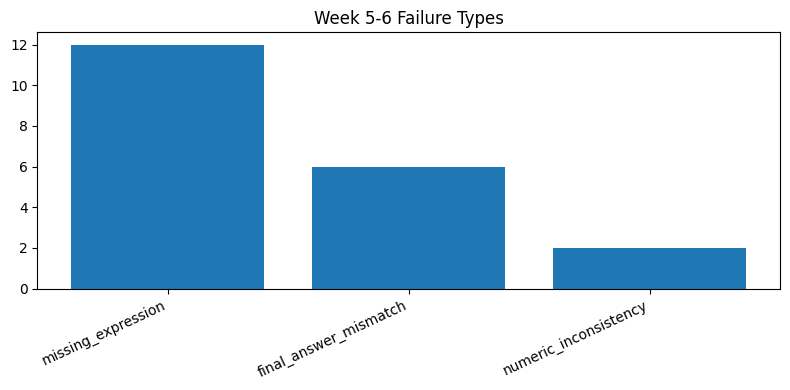

In [40]:
# Week 5-6 / Step 3: failure-class diagnostics

error_counter = Counter()
for rec in review_records:
    for vr in rec.verifier_results:
        if vr.get('error_type'):
            error_counter[vr['error_type']] += 1

diag_rows = [{'error_type': et, 'count': c} for et, c in error_counter.most_common()]
if pd is not None:
    display(pd.DataFrame(diag_rows))
else:
    pprint(diag_rows)

if plt is not None and diag_rows:
    plt.figure(figsize=(8,4))
    plt.bar([r['error_type'] for r in diag_rows], [r['count'] for r in diag_rows])
    plt.xticks(rotation=25, ha='right')
    plt.title('Week 5-6 Failure Types')
    plt.tight_layout()
    plt.show()


## Weeks 7-8: Logic Extension + Publication Gate (Implemented)

Goal:
- add a narrow logic verifier extension,
- keep logic metrics separate from arithmetic metrics,
- enforce publication readiness with artifact hashes and a dataset card.


In [41]:
# Week 7-8 / Step 1: run separate logic benchmark demo

from verifier_guided_reasoning.logic_pipeline import run_logic_demo

logic_summary = run_logic_demo(
    output_path='artifacts/eval/logic_summary.json',
    tracker_root=str(mlflow_root),
)

print('Logic metrics:')
pprint({k: logic_summary[k] for k in ['num_traces', 'logic_label_accuracy', 'pass_rate', 'error_counts']})
if pd is not None:
    display(pd.DataFrame(logic_summary.get('traces', [])))


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 383, in search_experiments
    exp = self._get_experiment(exp_id, view_type)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 481, in _get_experiment
    meta = FileStore._read_yaml(experiment_dir, FileStore.META_DATA_FILE_NAME)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 1670, in _read_yaml
    return _read_helper(root, file_name, attempts_remaining=retries)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/mlflow/store/tracking/file_store.py", line 1663, in _read_helper
    result = read_yaml(root, file_name)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.1

Logic metrics:
{'error_counts': {'final_answer_mismatch': 1, 'logic_label_mismatch': 1},
 'logic_label_accuracy': 0.6667,
 'num_traces': 3,
 'pass_rate': 0.6667}


,sample_id,source_dataset,final_status,expected_label,predicted_label,num_failures,error_types
0,logic-demo-1,tasksource/folio,pass,entailment,entailment,0,[]
1,logic-demo-2,tasksource/folio,pass,contradiction,contradiction,0,[]
2,logic-demo-3,tasksource/folio,fail,unknown,entailment,2,"[logic_label_mismatch, final_answer_mismatch]"


In [43]:
arith_panel = {
    'task': 'arithmetic',
    'num_traces': arith_summary.get('num_traces'),
    'final_accuracy': arith_summary.get('final_accuracy'),
    'pass_rate': arith_summary.get('pass_rate'),
    'top_errors': arith_summary.get('error_counts', {}),
}

logic_panel = {
    'task': 'logic_entailment',
    'num_traces': logic_summary.get('num_traces'),
    'logic_label_accuracy': logic_summary.get('logic_label_accuracy'),
    'pass_rate': logic_summary.get('pass_rate'),
    'top_errors': logic_summary.get('error_counts', {}),
}

print('Arithmetic panel (separate):')
pprint(arith_panel)
print('Logic panel (separate):')
pprint(logic_panel)

if pd is not None:
    display(pd.DataFrame([
        {'task': 'arithmetic', 'accuracy_metric': arith_panel['final_accuracy'], 'pass_rate': arith_panel['pass_rate']},
        {'task': 'logic_entailment', 'accuracy_metric': logic_panel['logic_label_accuracy'], 'pass_rate': logic_panel['pass_rate']},
    ]))

Arithmetic panel (separate):
{'final_accuracy': 1.0,
 'num_traces': 2,
 'pass_rate': 0.75,
 'task': 'arithmetic',
 'top_errors': {'numeric_inconsistency': 1}}
Logic panel (separate):
{'logic_label_accuracy': 0.6667,
 'num_traces': 3,
 'pass_rate': 0.6667,
 'task': 'logic_entailment',
 'top_errors': {'final_answer_mismatch': 1, 'logic_label_mismatch': 1}}


,task,accuracy_metric,pass_rate
0,arithmetic,1.0000,0.7500
1,logic_entailment,0.6667,0.6667


In [44]:
# Week 7-8 / Step 3: reproducibility gate + dataset card generation

from verifier_guided_reasoning.publishing import build_artifact_manifest, reproducibility_gate, write_dataset_card
from IPython.display import Javascript

publish_dir = Path('artifacts/publish')
publish_dir.mkdir(parents=True, exist_ok=True)

artifact_paths = [
    Path('artifacts/eval/demo_summary.json'),
    Path('artifacts/eval/logic_summary.json'),
    Path('artifacts/curation/sft_curated.jsonl'),
    Path('artifacts/curation/preferences_curated.jsonl'),
]
manifest = build_artifact_manifest(artifact_paths)
repro_ok, repro_issues = reproducibility_gate(manifest)

if pd is not None:
    display(pd.DataFrame(manifest))
else:
    pprint(manifest)

combined_metrics = {
    'arithmetic_final_accuracy': float(arith_summary.get('final_accuracy', 0.0)),
    'logic_label_accuracy': float(logic_summary.get('logic_label_accuracy', 0.0)),
    'curation_acceptance_rate': float(review_metrics.get('acceptance_rate', 0.0)),
}

card_path = write_dataset_card(
    output_path=publish_dir / 'dataset_card.md',
    title='Verifier-Guided Curated Arithmetic + Logic Dataset',
    overview='Curated reasoning traces with deterministic arithmetic and logic verification for data-quality-aware model improvement.',
    metrics=combined_metrics,
    manifest=manifest,
    release_notes=[
        'Arithmetic and logic metrics are intentionally tracked in separate sections.',
        'Publish only when reproducibility gate passes.',
    ] + repro_issues,
)

print({'reproducibility_gate_passed': repro_ok, 'dataset_card': str(card_path)})
print(card_path.read_text(encoding='utf-8')[:1200])

try:
    display(Javascript("alert('Week 7-8 publication gate complete. Check reproducibility status before publishing.')"))
except Exception:
    pass


,path,exists,bytes,sha256
0,artifacts/eval/demo_summary.json,True,586,03a76f3274138e6f4343c8c96d3ad36f43f6a9e9540821...
1,artifacts/eval/logic_summary.json,True,1111,fd287ffcd58760aa3c989607bb17436883e650f7f82476...
2,artifacts/curation/sft_curated.jsonl,True,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...
3,artifacts/curation/preferences_curated.jsonl,True,0,e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b93...


{'reproducibility_gate_passed': False, 'dataset_card': 'artifacts/publish/dataset_card.md'}
# Verifier-Guided Curated Arithmetic + Logic Dataset

Generated at: 2026-04-29T18:48:58.555763+00:00

## Overview
Curated reasoning traces with deterministic arithmetic and logic verification for data-quality-aware model improvement.

## Metrics
- arithmetic_final_accuracy: 1.0
- logic_label_accuracy: 0.6667
- curation_acceptance_rate: 0.0

## Artifact Manifest
- `artifacts/eval/demo_summary.json` | exists=True | bytes=586 | sha256=03a76f3274138e6f4343c8c96d3ad36f43f6a9e95408218f9dbe453b4b3ba4ff
- `artifacts/eval/logic_summary.json` | exists=True | bytes=1111 | sha256=fd287ffcd58760aa3c989607bb17436883e650f7f824767cb09f78db46766657
- `artifacts/curation/sft_curated.jsonl` | exists=True | bytes=0 | sha256=e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934ca495991b7852b855
- `artifacts/curation/preferences_curated.jsonl` | exists=True | bytes=0 | sha256=e3b0c44298fc1c149afbf4c8996fb92427ae41e4649b934

<IPython.core.display.Javascript object>

In [45]:
# Week 7-8 / Step 4: publication checklist panel for employer-facing demo

publish_checks = [
    {'check': 'Arithmetic evaluation artifact exists', 'passed': Path('artifacts/eval/demo_summary.json').exists()},
    {'check': 'Logic evaluation artifact exists', 'passed': Path('artifacts/eval/logic_summary.json').exists()},
    {'check': 'Curated SFT export exists', 'passed': Path('artifacts/curation/sft_curated.jsonl').exists()},
    {'check': 'Curated preference export exists', 'passed': Path('artifacts/curation/preferences_curated.jsonl').exists()},
    {'check': 'Reproducibility gate passed', 'passed': repro_ok},
]

all_passed = all(item['passed'] for item in publish_checks)

if pd is not None:
    display(pd.DataFrame(publish_checks))
else:
    pprint(publish_checks)

print('Publication readiness:', 'READY' if all_passed else 'NOT READY')


,check,passed
0,Arithmetic evaluation artifact exists,True
1,Logic evaluation artifact exists,True
2,Curated SFT export exists,True
3,Curated preference export exists,True
4,Reproducibility gate passed,False


Publication readiness: NOT READY


In [46]:
print('Notebook status: Weeks 1-8 implemented with arithmetic + logic separation and publication gate checks.')


Notebook status: Weeks 1-8 implemented with arithmetic + logic separation and publication gate checks.
